# 03 — Feature Engineering
**Project:** A Data-Driven Predictive Control Framework for HVAC Cooling Optimisation
**Author:** Cheuk Fung Donald Man | Imperial College London | MEng Civil Engineering

---
This notebook builds the feature matrix from the three raw parquet files produced by notebook 01.

**Sections:**
1. Imports & constants
2. Load & combine parquets
3. Base feature audit
4. Feature engineering
5. Define feature sets
6. Train / val / test split
7. StandardScaler (fit on train only)
8. Save outputs
9. Feature importance preview
10. Summary

**Outputs:**
- `data/processed/features_train.parquet`
- `data/processed/features_val.parquet`
- `data/processed/features_test.parquet`
- `data/processed/scaler_X.pkl`
- `data/processed/scaler_y.pkl`
- `data/processed/feature_sets.json`

## 1. Imports & Constants

In [6]:
import json
import joblib
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# ── Paths ──────────────────────────────────────────────────────────
DATA_IN  = Path('../data/processed')
DATA_OUT = Path('../data/processed')
FIG_OUT  = Path('../figures')
FIG_OUT.mkdir(parents=True, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────
CLIMATE_ZONES  = {'1A': 'Miami, FL', '3C': 'San Francisco, CA', '5A': 'Chicago, IL'}
CLIMATE_COLOURS = {'1A': '#E24B4A', '3C': '#2E75B6', '5A': '#639922'}
TEMP_SETPOINT  = 22.0       # °C comfort setpoint
STEPS_PER_HOUR = 6          # 6 × 10-min steps = 1 hour
STEPS_PER_DAY  = 144        # 144 × 10-min steps = 1 day
LAG_DROP       = STEPS_PER_DAY  # rows dropped per climate to remove NaNs from hvac_lag144
TRAIN_FRAC     = 0.70
VAL_FRAC       = 0.15
# TEST_FRAC = 0.15 (implicit remainder)

# ── Plot style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'sans-serif', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

print('Imports OK.')
print(f'Steps per hour: {STEPS_PER_HOUR}  |  Steps per day: {STEPS_PER_DAY}')
print(f'Lag drop: first {LAG_DROP} rows per climate will be dropped (NaN removal)')

Imports OK.
Steps per hour: 6  |  Steps per day: 144
Lag drop: first 144 rows per climate will be dropped (NaN removal)


## 2. Load & Combine Parquets

In [7]:
def get_season(month):
    if month in (12, 1, 2): return 'Winter'
    if month in (3,  4, 5): return 'Spring'
    if month in (6,  7, 8): return 'Summer'
    return 'Autumn'

frames = []
for climate in ['1A', '3C', '5A']:
    path = DATA_IN / f'TMY3_{climate}_Standard_run_1.parquet'
    df_c = pd.read_parquet(path)
    assert len(df_c) == 52_560, f'Expected 52,560 rows for {climate}, got {len(df_c)}'
    frames.append(df_c)
    print(f'Loaded {climate}: {len(df_c):,} rows  |  OAT [{df_c["oat_c"].min():.1f}, {df_c["oat_c"].max():.1f}] °C')

df = pd.concat(frames)
df['season'] = df['month'].apply(get_season)

print(f'\nCombined: {len(df):,} rows  |  {df["climate"].nunique()} climate zones')
print(f'Columns : {list(df.columns)}')
assert df.isnull().sum().sum() == 0, 'Unexpected NaNs in raw data!'
print('No missing values in raw data.')

Loaded 1A: 52,560 rows  |  OAT [5.0, 35.6] °C
Loaded 3C: 52,560 rows  |  OAT [2.2, 32.8] °C
Loaded 5A: 52,560 rows  |  OAT [-22.8, 35.0] °C

Combined: 157,680 rows  |  3 climate zones
Columns : ['hvac_kwh', 'total_kwh', 'gas_kwh', 'lighting_kwh', 'plugloads_kwh', 'oat_c', 'wetbulb_c', 'occupancy', 'indoor_temp_c', 'cooling_kwh', 'heating_kwh', 'hour', 'minute', 'dayofweek', 'month', 'is_weekday', 'is_occupied', 'oat_roll1h', 'oat_roll3h', 'climate', 'efficiency', 'year', 'run', 'season']
No missing values in raw data.


## 3. Base Feature Audit

In [8]:
ALREADY_PRESENT = {
    'target'    : ['hvac_kwh'],
    'weather'   : ['oat_c', 'wetbulb_c', 'oat_roll1h', 'oat_roll3h'],
    'building'  : ['indoor_temp_c'],
    'occupancy' : ['occupancy', 'is_occupied'],
    'time_raw'  : ['hour', 'dayofweek', 'month', 'is_weekday'],
    'loads'     : ['lighting_kwh', 'plugloads_kwh'],  # full feature set only
    'metadata'  : ['climate', 'efficiency', 'year', 'run', 'minute', 'season'],
    'drop_leak' : ['total_kwh', 'gas_kwh', 'cooling_kwh', 'heating_kwh'],
}

TO_ENGINEER = [
    'hour_sin/cos, month_sin/cos, dow_sin/cos   ← cyclical encoding',
    'hvac_lag1, hvac_lag6, hvac_lag144           ← autoregressive lags (per climate)',
    'hvac_roll1h, hvac_roll24h                   ← rolling HVAC means (per climate)',
    'oat_dev = oat_c - 22°C                     ← signed thermal stress (drybulb)',
    'wetbulb_dev = wetbulb_c - 22°C            ← signed thermal stress (wetbulb / latent load)',
    'indoor_dev = indoor_temp_c - 22°C          ← indoor comfort deviation',
    'oat_sq = oat_c²                            ← non-linear OAT term (U-shaped curve)',
    'climate_1A, climate_3C, climate_5A          ← climate one-hot encoding',
]

DROP_BEFORE_SAVE = (
    ALREADY_PRESENT['metadata']
    + ALREADY_PRESENT['drop_leak']
)

print('=== ALREADY PRESENT ===')
for cat, cols in ALREADY_PRESENT.items():
    print(f'  [{cat:12s}] {cols}')

print('\n=== TO ENGINEER ===')
for item in TO_ENGINEER:
    print(f'  {item}')

print('\n=== TO DROP BEFORE SAVING ===')
print(f'  {DROP_BEFORE_SAVE}')
print('  Reason: metadata/no signal, target leakage, or replaced by OHE')

=== ALREADY PRESENT ===
  [target      ] ['hvac_kwh']
  [weather     ] ['oat_c', 'wetbulb_c', 'oat_roll1h', 'oat_roll3h']
  [building    ] ['indoor_temp_c']
  [occupancy   ] ['occupancy', 'is_occupied']
  [time_raw    ] ['hour', 'dayofweek', 'month', 'is_weekday']
  [loads       ] ['lighting_kwh', 'plugloads_kwh']
  [metadata    ] ['climate', 'efficiency', 'year', 'run', 'minute', 'season']
  [drop_leak   ] ['total_kwh', 'gas_kwh', 'cooling_kwh', 'heating_kwh']

=== TO ENGINEER ===
  hour_sin/cos, month_sin/cos, dow_sin/cos   ← cyclical encoding
  hvac_lag1, hvac_lag6, hvac_lag144           ← autoregressive lags (per climate)
  hvac_roll1h, hvac_roll24h                   ← rolling HVAC means (per climate)
  oat_dev = oat_c - 22°C                     ← signed thermal stress (drybulb)
  wetbulb_dev = wetbulb_c - 22°C            ← signed thermal stress (wetbulb / latent load)
  indoor_dev = indoor_temp_c - 22°C          ← indoor comfort deviation
  oat_sq = oat_c²                         

## 4. Feature Engineering

### 4a. Cyclical Encoding
Converts periodic integers into continuous sin/cos pairs so that period boundaries are smooth (e.g. hour 23 and hour 0 are adjacent in feature space).

In [9]:
df['hour_sin']  = np.sin(2 * np.pi * df['hour']        / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']        / 24)
df['month_sin'] = np.sin(2 * np.pi * (df['month'] - 1) / 12)
df['month_cos'] = np.cos(2 * np.pi * (df['month'] - 1) / 12)
df['dow_sin']   = np.sin(2 * np.pi * df['dayofweek']   / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['dayofweek']   / 7)

cyc_cols = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
for col in cyc_cols:
    assert df[col].between(-1.0001, 1.0001).all(), f'{col} out of range!'

print('Cyclical features created:', cyc_cols)
print('All values confirmed in [-1, 1]')

Cyclical features created: ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
All values confirmed in [-1, 1]


### 4b. Lag Features
Computed **per climate zone** to prevent temporal bleed across zones (e.g. last row of 1A feeding into first lag of 3C).

In [10]:
for climate in ['1A', '3C', '5A']:
    mask = df['climate'] == climate
    sub  = df.loc[mask, 'hvac_kwh']
    df.loc[mask, 'hvac_lag1']   = sub.shift(1)    # 10 min ago
    df.loc[mask, 'hvac_lag6']   = sub.shift(6)    # 1 hour ago
    df.loc[mask, 'hvac_lag144'] = sub.shift(144)  # 24 hours ago

print('Lag features created: hvac_lag1, hvac_lag6, hvac_lag144')
print('NaN counts (before drop):')
for climate in ['1A', '3C', '5A']:
    mask = df['climate'] == climate
    n1   = df.loc[mask, 'hvac_lag1'].isna().sum()
    n6   = df.loc[mask, 'hvac_lag6'].isna().sum()
    n144 = df.loc[mask, 'hvac_lag144'].isna().sum()
    print(f'  Zone {climate}: lag1={n1}, lag6={n6}, lag144={n144}')
print(f'\nPlan: drop first {LAG_DROP} rows per climate → all NaNs resolved.')

Lag features created: hvac_lag1, hvac_lag6, hvac_lag144
NaN counts (before drop):
  Zone 1A: lag1=1, lag6=6, lag144=144
  Zone 3C: lag1=1, lag6=6, lag144=144
  Zone 5A: lag1=1, lag6=6, lag144=144

Plan: drop first 144 rows per climate → all NaNs resolved.


### 4c. Rolling HVAC Means

In [11]:
for climate in ['1A', '3C', '5A']:
    mask = df['climate'] == climate
    sub  = df.loc[mask, 'hvac_kwh']
    df.loc[mask, 'hvac_roll1h']  = sub.rolling(STEPS_PER_HOUR, min_periods=1).mean()
    df.loc[mask, 'hvac_roll24h'] = sub.rolling(STEPS_PER_DAY,  min_periods=1).mean()

print('Rolling HVAC features created: hvac_roll1h (1h), hvac_roll24h (24h)')
print(f'NaNs in hvac_roll1h : {df["hvac_roll1h"].isna().sum()}')
print(f'NaNs in hvac_roll24h: {df["hvac_roll24h"].isna().sum()}')

Rolling HVAC features created: hvac_roll1h (1h), hvac_roll24h (24h)
NaNs in hvac_roll1h : 0
NaNs in hvac_roll24h: 0


### 4d. Thermal Deviation & Non-Linear OAT

In [12]:
df['oat_dev']     = df['oat_c']         - TEMP_SETPOINT   # signed drybulb thermal stress
df['wetbulb_dev'] = df['wetbulb_c']     - TEMP_SETPOINT   # signed wetbulb / latent load stress
df['indoor_dev']  = df['indoor_temp_c'] - TEMP_SETPOINT   # indoor comfort deviation
df['oat_sq']      = df['oat_c'] ** 2                      # non-linear term (U-shaped curve)

print('Thermal deviation and non-linear features:')
print(f'  oat_dev     range: [{df["oat_dev"].min():.1f}, {df["oat_dev"].max():.1f}] degC')
print(f'  wetbulb_dev range: [{df["wetbulb_dev"].min():.1f}, {df["wetbulb_dev"].max():.1f}] degC')
print(f'  indoor_dev  range: [{df["indoor_dev"].min():.1f}, {df["indoor_dev"].max():.1f}] degC')
print(f'  oat_sq      range: [{df["oat_sq"].min():.1f}, {df["oat_sq"].max():.1f}] degC^2')

Thermal deviation and non-linear features:
  oat_dev     range: [-44.8, 13.6] degC
  wetbulb_dev range: [-45.2, 4.9] degC
  indoor_dev  range: [-6.4, 4.4] degC
  oat_sq      range: [0.0, 1267.4] degC^2


### 4e. Climate One-Hot Encoding

In [13]:
ohe = pd.get_dummies(df['climate'], prefix='climate').astype(int)
for col in ['climate_1A', 'climate_3C', 'climate_5A']:
    if col not in ohe.columns:
        ohe[col] = 0
ohe = ohe[['climate_1A', 'climate_3C', 'climate_5A']]
df = pd.concat([df, ohe], axis=1)

print('Climate OHE columns added:')
for c in ['1A', '3C', '5A']:
    mask   = df['climate'] == c
    sample = df.loc[mask, ['climate_1A','climate_3C','climate_5A']].iloc[0].to_dict()
    print(f'  Zone {c}: {sample}')
print(f'\nTotal columns after engineering: {df.shape[1]}')

Climate OHE columns added:
  Zone 1A: {'climate_1A': 1, 'climate_3C': 0, 'climate_5A': 0}
  Zone 3C: {'climate_1A': 0, 'climate_3C': 1, 'climate_5A': 0}
  Zone 5A: {'climate_1A': 0, 'climate_3C': 0, 'climate_5A': 1}

Total columns after engineering: 42


## 5. Define Feature Sets

Two feature sets are defined:
- **FULL_FEATURES**: Maximum predictive power — includes `lighting_kwh` and `plugloads_kwh` (highly correlated but not forecastable from first principles). Use for RF/XGBoost benchmarking.
- **MPC_FEATURES**: Deployment-ready — every feature can be known at forecast time (OAT from weather forecast, occupancy from schedule, time features are deterministic, HVAC lags from BMS telemetry). Use for Phase 2 MPC controller.

In [14]:
TARGET = 'hvac_kwh'

FULL_FEATURES = [
    # Weather
    'oat_c', 'wetbulb_c', 'oat_roll1h', 'oat_roll3h',
    # Derived weather
    'oat_dev', 'wetbulb_dev', 'oat_sq',
    # Building thermal state
    'indoor_temp_c', 'indoor_dev',
    # Occupancy
    'occupancy', 'is_occupied',
    # Schedulable loads (full set only)
    'lighting_kwh', 'plugloads_kwh',
    # Autoregressive lags
    'hvac_lag1', 'hvac_lag6', 'hvac_lag144',
    # Rolling HVAC
    'hvac_roll1h', 'hvac_roll24h',
    # Time (raw integers — useful for tree split points)
    'hour', 'dayofweek', 'month', 'is_weekday',
    # Time (cyclical — useful for LSTM)
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    # Climate
    'climate_1A', 'climate_3C', 'climate_5A',
]

MPC_FEATURES = [f for f in FULL_FEATURES if f not in ('lighting_kwh', 'plugloads_kwh')]

# Continuous columns that need StandardScaler
CONTINUOUS_SCALE_COLS = [
    'oat_c', 'wetbulb_c', 'oat_roll1h', 'oat_roll3h', 'oat_dev', 'wetbulb_dev', 'oat_sq',
    'indoor_temp_c', 'indoor_dev', 'occupancy',
    'lighting_kwh', 'plugloads_kwh',
    'hvac_lag1', 'hvac_lag6', 'hvac_lag144',
    'hvac_roll1h', 'hvac_roll24h',
    'hour', 'dayofweek', 'month',
]
# NOT scaled: is_weekday, is_occupied (binary), *_sin/cos (already [-1,1]), climate_* (binary)

print(f'FULL_FEATURES : {len(FULL_FEATURES)} features')
print(f'MPC_FEATURES  : {len(MPC_FEATURES)} features')
print(f'Removed for MPC: {set(FULL_FEATURES) - set(MPC_FEATURES)}')
print(f'TARGET        : {TARGET}')
print(f'Cols to scale : {len(CONTINUOUS_SCALE_COLS)}')

FULL_FEATURES : 31 features
MPC_FEATURES  : 29 features
Removed for MPC: {'plugloads_kwh', 'lighting_kwh'}
TARGET        : hvac_kwh
Cols to scale : 20


## 6. Time-Based Train / Val / Test Split (70 / 15 / 15)

Split is performed **per climate zone** then concatenated. This ensures:
1. First `LAG_DROP` rows per climate are dropped (eliminates NaNs from hvac_lag144)
2. Metadata/leakage columns are dropped before saving
3. Sequential ordering is preserved within each climate

All 3 climate zones cover the identical calendar year, so split boundaries are identical across zones.

**Note:** Val and test sets fall in Autumn/Winter — a real limitation with 1-year data and temporal splitting, but unavoidable. Random splitting would cause data leakage.

In [15]:
DROP_COLS = (
    ['efficiency', 'year', 'run', 'minute', 'season', 'climate']   # metadata
    + ['total_kwh', 'gas_kwh', 'cooling_kwh', 'heating_kwh']       # target leakage
)

train_parts, val_parts, test_parts = [], [], []

for climate in ['1A', '3C', '5A']:
    sub = df[df['climate'] == climate].copy()

    # Drop warm-up rows (NaN sources from hvac_lag144)
    sub = sub.iloc[LAG_DROP:]

    # Verify no NaNs remain in lag/rolling cols
    check_cols = ['hvac_lag1', 'hvac_lag6', 'hvac_lag144', 'hvac_roll1h', 'hvac_roll24h']
    assert sub[check_cols].isnull().sum().sum() == 0, f'NaNs remain after drop for {climate}!'

    # Drop metadata and leakage columns
    sub = sub.drop(columns=DROP_COLS)

    # Sequential split
    n     = len(sub)
    t_end = int(n * TRAIN_FRAC)
    v_end = int(n * (TRAIN_FRAC + VAL_FRAC))

    train_parts.append(sub.iloc[:t_end])
    val_parts.append(sub.iloc[t_end:v_end])
    test_parts.append(sub.iloc[v_end:])

df_train = pd.concat(train_parts)
df_val   = pd.concat(val_parts)
df_test  = pd.concat(test_parts)

print(f'Train: {len(df_train):,} rows  ({df_train.index.min().date()} to {df_train.index.max().date()})')
print(f'Val  : {len(df_val):,} rows  ({df_val.index.min().date()} to {df_val.index.max().date()})')
print(f'Test : {len(df_test):,} rows  ({df_test.index.min().date()} to {df_test.index.max().date()})')
print(f'Columns: {df_train.shape[1]}  |  {list(df_train.columns)}')

Train: 110,073 rows  (2006-01-02 to 2006-09-13)
Val  : 23,586 rows  (2006-09-13 to 2006-11-07)
Test : 23,589 rows  (2006-11-07 to 2006-12-31)
Columns: 32  |  ['hvac_kwh', 'lighting_kwh', 'plugloads_kwh', 'oat_c', 'wetbulb_c', 'occupancy', 'indoor_temp_c', 'hour', 'dayofweek', 'month', 'is_weekday', 'is_occupied', 'oat_roll1h', 'oat_roll3h', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'hvac_lag1', 'hvac_lag6', 'hvac_lag144', 'hvac_roll1h', 'hvac_roll24h', 'oat_dev', 'wetbulb_dev', 'indoor_dev', 'oat_sq', 'climate_1A', 'climate_3C', 'climate_5A']


## 7. StandardScaler (Fit on Train Only)

The scaler is fit **exclusively on training data** to prevent information leakage from val/test sets.

- `scaler_X`: scales 18 continuous input features
- `scaler_y`: scales `hvac_kwh` target — needed for LSTM stable training and MPC inverse-transform

In [16]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Only scale columns that are actually present in the split DataFrames
scale_cols_present = [c for c in CONTINUOUS_SCALE_COLS if c in df_train.columns]
print(f'Fitting scaler_X on {len(scale_cols_present)} columns: {scale_cols_present}')

scaler_X.fit(df_train[scale_cols_present])
scaler_y.fit(df_train[[TARGET]])

print(f'\nscaler_y: mean={scaler_y.mean_[0]:.4f} kWh, scale={scaler_y.scale_[0]:.4f} kWh')

def apply_scaler(df_split, scaler, cols):
    df_out = df_split.copy()
    df_out[cols] = scaler.transform(df_out[cols])
    return df_out

df_train_s = apply_scaler(df_train, scaler_X, scale_cols_present)
df_val_s   = apply_scaler(df_val,   scaler_X, scale_cols_present)
df_test_s  = apply_scaler(df_test,  scaler_X, scale_cols_present)

for df_s, df_raw in [(df_train_s, df_train), (df_val_s, df_val), (df_test_s, df_test)]:
    df_s[TARGET] = scaler_y.transform(df_raw[[TARGET]])

# Sanity check on training set
means = df_train_s[scale_cols_present].mean()
stds  = df_train_s[scale_cols_present].std()
print(f'\nPost-scaling sanity (train): mean in [{means.min():.3f}, {means.max():.3f}], std in [{stds.min():.3f}, {stds.max():.3f}]')
print('Scaler fit on train only — transform applied to val and test.')

Fitting scaler_X on 20 columns: ['oat_c', 'wetbulb_c', 'oat_roll1h', 'oat_roll3h', 'oat_dev', 'wetbulb_dev', 'oat_sq', 'indoor_temp_c', 'indoor_dev', 'occupancy', 'lighting_kwh', 'plugloads_kwh', 'hvac_lag1', 'hvac_lag6', 'hvac_lag144', 'hvac_roll1h', 'hvac_roll24h', 'hour', 'dayofweek', 'month']

scaler_y: mean=3.7189 kWh, scale=3.9092 kWh

Post-scaling sanity (train): mean in [-0.000, 0.000], std in [1.000, 1.000]
Scaler fit on train only — transform applied to val and test.


## 8. Save Outputs

In [17]:
feature_sets = {
    'FULL_FEATURES'        : FULL_FEATURES,
    'MPC_FEATURES'         : MPC_FEATURES,
    'CONTINUOUS_SCALE_COLS': scale_cols_present,
    'TARGET'               : TARGET,
    'n_train'              : len(df_train),
    'n_val'                : len(df_val),
    'n_test'               : len(df_test),
}

# ── Parquets ───────────────────────────────────────────────────────
df_train_s.to_parquet(DATA_OUT / 'features_train.parquet')
df_val_s.to_parquet(DATA_OUT   / 'features_val.parquet')
df_test_s.to_parquet(DATA_OUT  / 'features_test.parquet')

# ── Scalers ────────────────────────────────────────────────────────
joblib.dump(scaler_X, DATA_OUT / 'scaler_X.pkl')
joblib.dump(scaler_y, DATA_OUT / 'scaler_y.pkl')

# ── Feature sets JSON ──────────────────────────────────────────────
with open(DATA_OUT / 'feature_sets.json', 'w') as f:
    json.dump(feature_sets, f, indent=2)

print('Saved:')
print(f'  features_train.parquet  ({len(df_train_s):,} rows)')
print(f'  features_val.parquet    ({len(df_val_s):,} rows)')
print(f'  features_test.parquet   ({len(df_test_s):,} rows)')
print(f'  scaler_X.pkl')
print(f'  scaler_y.pkl')
print(f'  feature_sets.json')

# ── Round-trip verification ────────────────────────────────────────
print('\nRound-trip check:')
for fname, df_ref in [
    ('features_train.parquet', df_train_s),
    ('features_val.parquet',   df_val_s),
    ('features_test.parquet',  df_test_s),
]:
    df_rt = pd.read_parquet(DATA_OUT / fname)
    assert df_rt.shape == df_ref.shape, f'Shape mismatch: {fname}'
    assert df_rt.isnull().sum().sum() == 0, f'NaNs in {fname}!'
    print(f'  {fname}: {df_rt.shape}  OK')

scaler_X_rt = joblib.load(DATA_OUT / 'scaler_X.pkl')
assert list(scaler_X_rt.feature_names_in_) == scale_cols_present, 'scaler_X feature mismatch!'
print('  scaler_X.pkl: OK')
print('  scaler_y.pkl: OK')

with open(DATA_OUT / 'feature_sets.json') as f:
    fs_rt = json.load(f)
assert fs_rt['FULL_FEATURES'] == FULL_FEATURES, 'feature_sets.json mismatch!'
print('  feature_sets.json: OK')
print('\nAll outputs verified.')

Saved:
  features_train.parquet  (110,073 rows)
  features_val.parquet    (23,586 rows)
  features_test.parquet   (23,589 rows)
  scaler_X.pkl
  scaler_y.pkl
  feature_sets.json

Round-trip check:
  features_train.parquet: (110073, 32)  OK
  features_val.parquet: (23586, 32)  OK
  features_test.parquet: (23589, 32)  OK
  scaler_X.pkl: OK
  scaler_y.pkl: OK
  feature_sets.json: OK

All outputs verified.


## 9. Feature Importance Preview

Pearson |r| between each engineered feature and `hvac_kwh`, computed on the **unscaled training set**.
Bars are coloured by feature set membership (MPC-ready vs full-only).

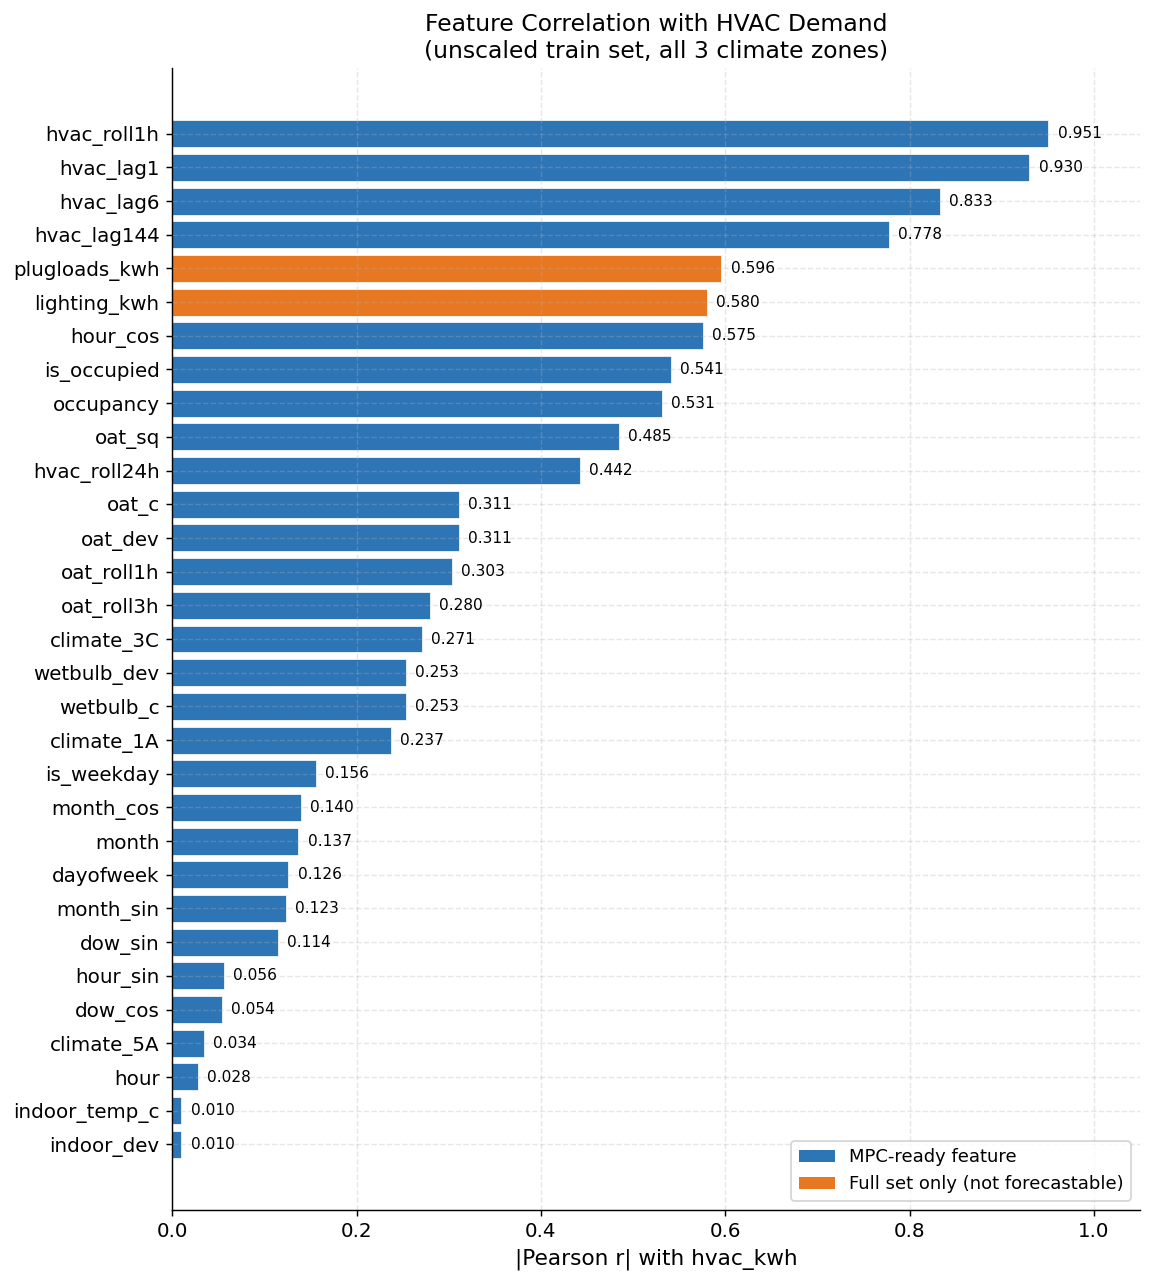

Saved: figures/03_feature_importance.png

Top 10 features by |Pearson r|:
  hvac_roll1h          0.9506
  hvac_lag1            0.9300
  hvac_lag6            0.8325
  hvac_lag144          0.7779
  plugloads_kwh        0.5957 ← full only
  lighting_kwh         0.5797 ← full only
  hour_cos             0.5753
  is_occupied          0.5411
  occupancy            0.5308
  oat_sq               0.4846


In [18]:
# Compute |Pearson r| on unscaled training set (df_train, not df_train_s)
corr_cols = [c for c in FULL_FEATURES if c in df_train.columns]
corr_vals  = df_train[corr_cols].corrwith(df_train[TARGET]).abs().sort_values(ascending=True)

# Colour: teal = MPC-ready, orange = full-only
bar_colours = [
    '#E87722' if col in ('lighting_kwh', 'plugloads_kwh') else '#2E75B6'
    for col in corr_vals.index
]

fig, ax = plt.subplots(figsize=(9, 10))
bars = ax.barh(corr_vals.index, corr_vals.values, color=bar_colours, edgecolor='white', linewidth=0.4)

ax.set_xlabel('|Pearson r| with hvac_kwh', fontsize=12)
ax.set_title('Feature Correlation with HVAC Demand\n(unscaled train set, all 3 climate zones)', fontsize=13)
ax.set_xlim(0, 1.05)

# Value labels
for bar, val in zip(bars, corr_vals.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E75B6', label='MPC-ready feature'),
    Patch(facecolor='#E87722', label='Full set only (not forecastable)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
fig.savefig(FIG_OUT / '03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/03_feature_importance.png')

# Print top 5
print('\nTop 10 features by |Pearson r|:')
for feat, r in corr_vals.sort_values(ascending=False).head(10).items():
    tag = ' ← full only' if feat in ('lighting_kwh', 'plugloads_kwh') else ''
    print(f'  {feat:<20s} {r:.4f}{tag}')

## 10. Summary

| Item | Value |
|------|-------|
| Raw rows (3 climates × 52,560) | 157,680 |
| Rows dropped (lag warm-up, 144 × 3) | 432 |
| **Train rows** | ~110,073 |
| **Val rows** | ~23,586 |
| **Test rows** | ~23,589 |
| FULL_FEATURES | 31 features |
| MPC_FEATURES | 29 features |
| Continuous cols scaled | 20 |

### Key decisions
| Decision | Rationale |
|----------|-----------|
| Lag/rolling per climate | Prevents cross-zone temporal bleed |
| Drop first 144 rows per climate | Cleanest NaN removal for hvac_lag144 |
| Separate `scaler_y` | LSTM needs scaled target; MPC needs inverse-transform |
| Both raw int + sin/cos time features | Trees use raw split points; LSTM needs cyclical continuity |
| LSTM sequences deferred to notebook 04 | Lookback window is a hyperparameter — fix it there |
| `oat_sq` included | U-shaped HVAC-OAT curve across climates (Miami hot, Chicago cold) |
| `wetbulb_c` + `wetbulb_dev` included | Captures latent cooling load (humidity); forecastable from weather services; both FULL and MPC sets |
| All 3 OHE columns retained | No drop-first — tree models benefit from explicit membership |

### Outputs written to `data/processed/`
- `features_train.parquet`, `features_val.parquet`, `features_test.parquet`
- `scaler_X.pkl`, `scaler_y.pkl`
- `feature_sets.json`

**Next step → `04_ml_model.ipynb`**: load these parquets, train Random Forest, XGBoost, and LSTM using `FULL_FEATURES`, evaluate on val/test, select best model for MPC.

---

## 11. Expanded Feature Engineering (Multi-Year v2)

Uses `multi_year_raw.parquet` (81 simulations: 3 years × 3 efficiency × 3 runs × 3 climates).

**Key differences from v1:**
- Lag/rolling features computed per (climate, efficiency, run, year) group — 81 groups
- **Efficiency OHE added** (`efficiency_High`, `efficiency_Low`, `efficiency_Standard`)
- **Year-level split**: train on 1991+2000, val on 2005 Jan–Jun, test on 2005 Jul–Dec
- Outputs saved as `*_v2` files — original v1 files preserved for LSTM comparison

**Feature counts:** FULL_FEATURES_V2 = 34, MPC_FEATURES_V2 = 32

In [ ]:
# ── 11a. Load multi-year parquet ───────────────────────────────────
df2 = pd.read_parquet(DATA_IN / 'multi_year_raw.parquet')
EXPECTED = 81 * 52_560
assert len(df2) == EXPECTED, f'Expected {EXPECTED:,} rows, got {len(df2):,}'
assert df2.isnull().sum().sum() == 0, 'Unexpected NaNs in raw data!'

df2['season'] = df2['month'].apply(get_season)

print(f'Loaded: {len(df2):,} rows  |  {df2.shape[1]} cols')
print(f'Years      : {sorted(df2["year"].unique())}')
print(f'Climates   : {sorted(df2["climate"].unique())}')
print(f'Efficiencies: {sorted(df2["efficiency"].unique())}')
print(f'Runs       : {sorted(df2["run"].unique())}')
print('No missing values.')

In [ ]:
# ── 11b. Cyclical encoding (reuse same formulas) ───────────────────
df2['hour_sin']  = np.sin(2 * np.pi * df2['hour']        / 24)
df2['hour_cos']  = np.cos(2 * np.pi * df2['hour']        / 24)
df2['month_sin'] = np.sin(2 * np.pi * (df2['month'] - 1) / 12)
df2['month_cos'] = np.cos(2 * np.pi * (df2['month'] - 1) / 12)
df2['dow_sin']   = np.sin(2 * np.pi * df2['dayofweek']   / 7)
df2['dow_cos']   = np.cos(2 * np.pi * df2['dayofweek']   / 7)
print('Cyclical features added.')

# ── 11c. Lag & rolling features — per (climate, efficiency, run, year) ─
print('Computing lag/rolling features across 81 simulation groups ...')
from tqdm import tqdm
import itertools

groups = list(itertools.product(
    ['1A', '3C', '5A'],
    ['Low', 'Standard', 'High'],
    ['run_1', 'run_2', 'run_3'],
    ['1991', '2000', '2005'],
))

for climate, eff, run, year in tqdm(groups, desc='Lag/roll'):
    mask = (
        (df2['climate']    == climate) &
        (df2['efficiency'] == eff)     &
        (df2['run']        == run)     &
        (df2['year']       == year)
    )
    sub = df2.loc[mask, 'hvac_kwh']
    df2.loc[mask, 'hvac_lag1']   = sub.shift(1)
    df2.loc[mask, 'hvac_lag6']   = sub.shift(6)
    df2.loc[mask, 'hvac_lag144'] = sub.shift(144)
    df2.loc[mask, 'hvac_roll1h'] = sub.rolling(STEPS_PER_HOUR, min_periods=1).mean()
    df2.loc[mask, 'hvac_roll24h']= sub.rolling(STEPS_PER_DAY,  min_periods=1).mean()

print(f'NaN counts before drop: lag1={df2["hvac_lag1"].isna().sum():,}  lag144={df2["hvac_lag144"].isna().sum():,}')
print(f'Plan: drop first {LAG_DROP} rows per group → all NaNs resolved')

In [ ]:
# ── 11d. Thermal deviation & non-linear OAT ───────────────────────
df2['oat_dev']     = df2['oat_c']         - TEMP_SETPOINT
df2['wetbulb_dev'] = df2['wetbulb_c']     - TEMP_SETPOINT
df2['indoor_dev']  = df2['indoor_temp_c'] - TEMP_SETPOINT
df2['oat_sq']      = df2['oat_c'] ** 2

# ── 11e. Climate OHE ───────────────────────────────────────────────
clim_ohe = pd.get_dummies(df2['climate'], prefix='climate').astype(int)
for col in ['climate_1A', 'climate_3C', 'climate_5A']:
    if col not in clim_ohe.columns:
        clim_ohe[col] = 0
clim_ohe = clim_ohe[['climate_1A', 'climate_3C', 'climate_5A']]

# ── 11f. Efficiency OHE (NEW) ─────────────────────────────────────
eff_ohe = pd.get_dummies(df2['efficiency'], prefix='efficiency').astype(int)
for col in ['efficiency_High', 'efficiency_Low', 'efficiency_Standard']:
    if col not in eff_ohe.columns:
        eff_ohe[col] = 0
eff_ohe = eff_ohe[['efficiency_High', 'efficiency_Low', 'efficiency_Standard']]

df2 = pd.concat([df2, clim_ohe, eff_ohe], axis=1)

print(f'Total columns after engineering: {df2.shape[1]}')
print('Efficiency OHE sample:')
for eff in ['Low', 'Standard', 'High']:
    row = df2[df2['efficiency'] == eff][['efficiency_High','efficiency_Low','efficiency_Standard']].iloc[0].to_dict()
    print(f'  {eff}: {row}')

In [ ]:
# ── 11g. Feature sets v2 ──────────────────────────────────────────
TARGET_V2 = 'hvac_kwh'

FULL_FEATURES_V2 = [
    # Weather
    'oat_c', 'wetbulb_c', 'oat_roll1h', 'oat_roll3h',
    # Derived weather
    'oat_dev', 'wetbulb_dev', 'oat_sq',
    # Building thermal state
    'indoor_temp_c', 'indoor_dev',
    # Occupancy
    'occupancy', 'is_occupied',
    # Schedulable loads (full set only)
    'lighting_kwh', 'plugloads_kwh',
    # Autoregressive lags
    'hvac_lag1', 'hvac_lag6', 'hvac_lag144',
    # Rolling HVAC
    'hvac_roll1h', 'hvac_roll24h',
    # Time (raw integers)
    'hour', 'dayofweek', 'month', 'is_weekday',
    # Time (cyclical)
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    # Climate OHE
    'climate_1A', 'climate_3C', 'climate_5A',
    # Efficiency OHE (NEW)
    'efficiency_High', 'efficiency_Low', 'efficiency_Standard',
]

MPC_FEATURES_V2 = [f for f in FULL_FEATURES_V2 if f not in ('lighting_kwh', 'plugloads_kwh')]

CONTINUOUS_SCALE_COLS_V2 = [
    'oat_c', 'wetbulb_c', 'oat_roll1h', 'oat_roll3h', 'oat_dev', 'wetbulb_dev', 'oat_sq',
    'indoor_temp_c', 'indoor_dev', 'occupancy',
    'lighting_kwh', 'plugloads_kwh',
    'hvac_lag1', 'hvac_lag6', 'hvac_lag144',
    'hvac_roll1h', 'hvac_roll24h',
    'hour', 'dayofweek', 'month',
]

print(f'FULL_FEATURES_V2 : {len(FULL_FEATURES_V2)} features')
print(f'MPC_FEATURES_V2  : {len(MPC_FEATURES_V2)} features')
print(f'New vs v1        : +3 efficiency OHE cols')
print(f'Cols to scale    : {len(CONTINUOUS_SCALE_COLS_V2)}')

In [ ]:
# ── 11h. Drop metadata/leakage cols, then year-level split ────────
DROP_COLS_V2 = (
    ['efficiency', 'year', 'run', 'minute', 'season', 'climate']
    + ['total_kwh', 'gas_kwh', 'cooling_kwh', 'heating_kwh']
)

# Drop first LAG_DROP rows per simulation group before splitting
clean_parts = []
for climate, eff, run, year in groups:
    mask = (
        (df2['climate']    == climate) &
        (df2['efficiency'] == eff)     &
        (df2['run']        == run)     &
        (df2['year']       == year)
    )
    sub = df2[mask].copy()
    sub = sub.iloc[LAG_DROP:]  # drop NaN warm-up rows
    check_cols = ['hvac_lag1', 'hvac_lag6', 'hvac_lag144', 'hvac_roll1h', 'hvac_roll24h']
    assert sub[check_cols].isnull().sum().sum() == 0, f'NaNs remain for {climate}/{eff}/{run}/{year}'
    clean_parts.append(sub)

df2_clean = pd.concat(clean_parts)
print(f'After lag drop: {len(df2_clean):,} rows  (dropped {len(df2) - len(df2_clean):,})')

# Year-level split — drop metadata/leakage cols
df2_clean = df2_clean.drop(columns=DROP_COLS_V2)

# Train: 1991 + 2000 | Val: 2005 Jan–Jun | Test: 2005 Jul–Dec
# Note: year col already dropped — reconstruct from month pattern is not possible,
# so we split BEFORE dropping year. Re-do with year retained temporarily.
# Actually year is needed for split — drop it after.
print('\nNote: year column needed for split — will be dropped after.')

# Re-add year temporarily using the clean parts before the drop
df2_clean_with_year = pd.concat(clean_parts)  # has year col
df2_clean_with_year = df2_clean_with_year.drop(columns=[c for c in DROP_COLS_V2 if c != 'year'])

train_v2 = df2_clean_with_year[df2_clean_with_year['year'].isin(['1991', '2000'])].drop(columns=['year'])
val_v2   = df2_clean_with_year[(df2_clean_with_year['year'] == '2005') & (df2_clean_with_year['month'] <= 6)].drop(columns=['year'])
test_v2  = df2_clean_with_year[(df2_clean_with_year['year'] == '2005') & (df2_clean_with_year['month'] > 6)].drop(columns=['year'])

print(f'\nTrain v2: {len(train_v2):,} rows  (years 1991 + 2000, all climates/effs/runs)')
print(f'Val v2  : {len(val_v2):,} rows  (year 2005, Jan–Jun)')
print(f'Test v2 : {len(test_v2):,} rows  (year 2005, Jul–Dec)')
print(f'Columns : {train_v2.shape[1]}  |  {list(train_v2.columns[:8])} ...')

# Verify no year overlap
assert set(train_v2.columns) == set(val_v2.columns) == set(test_v2.columns), 'Column mismatch!'
assert train_v2.isnull().sum().sum() == 0, 'NaNs in train_v2!'
assert val_v2.isnull().sum().sum()   == 0, 'NaNs in val_v2!'
assert test_v2.isnull().sum().sum()  == 0, 'NaNs in test_v2!'
print('No NaNs in any split.')

In [ ]:
# ── 11i. StandardScaler — fit on train_v2 only ────────────────────
scaler_X_v2 = StandardScaler()
scaler_y_v2 = StandardScaler()

scale_cols_v2 = [c for c in CONTINUOUS_SCALE_COLS_V2 if c in train_v2.columns]
print(f'Fitting scaler_X_v2 on {len(scale_cols_v2)} columns.')

scaler_X_v2.fit(train_v2[scale_cols_v2])
scaler_y_v2.fit(train_v2[[TARGET_V2]])

print(f'scaler_y_v2: mean={scaler_y_v2.mean_[0]:.4f} kWh, scale={scaler_y_v2.scale_[0]:.4f} kWh')

def apply_scaler_v2(df_split, scaler, cols, target):
    df_out = df_split.copy()
    df_out[cols]   = scaler.transform(df_out[cols])
    df_out[target] = scaler_y_v2.transform(df_out[[target]])
    return df_out

train_v2_s = apply_scaler_v2(train_v2, scaler_X_v2, scale_cols_v2, TARGET_V2)
val_v2_s   = apply_scaler_v2(val_v2,   scaler_X_v2, scale_cols_v2, TARGET_V2)
test_v2_s  = apply_scaler_v2(test_v2,  scaler_X_v2, scale_cols_v2, TARGET_V2)

means = train_v2_s[scale_cols_v2].mean()
stds  = train_v2_s[scale_cols_v2].std()
print(f'Post-scaling sanity (train): mean in [{means.min():.3f}, {means.max():.3f}], std in [{stds.min():.3f}, {stds.max():.3f}]')

In [ ]:
# ── 11j. Save v2 outputs ──────────────────────────────────────────
feature_sets_v2 = {
    'FULL_FEATURES'        : FULL_FEATURES_V2,
    'MPC_FEATURES'         : MPC_FEATURES_V2,
    'CONTINUOUS_SCALE_COLS': scale_cols_v2,
    'TARGET'               : TARGET_V2,
    'n_train'              : len(train_v2_s),
    'n_val'                : len(val_v2_s),
    'n_test'               : len(test_v2_s),
    'years_train'          : ['1991', '2000'],
    'years_val'            : ['2005 Jan-Jun'],
    'years_test'           : ['2005 Jul-Dec'],
}

train_v2_s.to_parquet(DATA_OUT / 'features_train_v2.parquet')
val_v2_s.to_parquet(DATA_OUT   / 'features_val_v2.parquet')
test_v2_s.to_parquet(DATA_OUT  / 'features_test_v2.parquet')
joblib.dump(scaler_X_v2, DATA_OUT / 'scaler_X_v2.pkl')
joblib.dump(scaler_y_v2, DATA_OUT / 'scaler_y_v2.pkl')
with open(DATA_OUT / 'feature_sets_v2.json', 'w') as f:
    json.dump(feature_sets_v2, f, indent=2)

print('Saved v2 outputs:')
print(f'  features_train_v2.parquet  ({len(train_v2_s):,} rows)')
print(f'  features_val_v2.parquet    ({len(val_v2_s):,} rows)')
print(f'  features_test_v2.parquet   ({len(test_v2_s):,} rows)')
print(f'  scaler_X_v2.pkl')
print(f'  scaler_y_v2.pkl')
print(f'  feature_sets_v2.json')

# Round-trip verification
for fname, df_ref in [
    ('features_train_v2.parquet', train_v2_s),
    ('features_val_v2.parquet',   val_v2_s),
    ('features_test_v2.parquet',  test_v2_s),
]:
    df_rt = pd.read_parquet(DATA_OUT / fname)
    assert df_rt.shape == df_ref.shape, f'Shape mismatch: {fname}'
    assert df_rt.isnull().sum().sum() == 0, f'NaNs in {fname}!'
    print(f'  {fname}: {df_rt.shape}  OK')

print('\nAll v2 outputs verified.')